In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [3]:
%pushd "/content/drive/MyDrive/MSSP607/Assignments"

/content/drive/MyDrive/MSSP607/Assignments


['/content']

In [4]:
df = pd.read_csv('/content/drive/MyDrive/MSSP607/Assignments/Assignment 4 + Final/global_data_on_sustainable_energy.csv')
df.head(40)

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.20,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60,652230.0,33.939110,67.709953
1,Afghanistan,2001,4.074574,7.20,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60,652230.0,33.939110,67.709953
2,Afghanistan,2002,9.409158,8.20,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60,652230.0,33.939110,67.709953
3,Afghanistan,2003,14.738506,9.50,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60,652230.0,33.939110,67.709953
4,Afghanistan,2004,20.064968,10.90,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60,652230.0,33.939110,67.709953
5,Afghanistan,2005,25.390894,12.20,7.51,9830000.0,33.88,0.34,0.0,0.59,...,252.06912,1.41,1549.999952,NaN,11.229715,242.031313,60,652230.0,33.939110,67.709953
6,Afghanistan,2006,30.718690,13.85,7.40,10620000.0,31.89,0.20,0.0,0.64,...,304.42090,1.50,1759.999990,NaN,5.357403,263.733602,60,652230.0,33.939110,67.709953
7,Afghanistan,2007,36.051010,15.30,7.25,15750000.0,28.78,0.20,0.0,0.75,...,354.27990,1.53,1769.999981,NaN,13.826320,359.693158,60,652230.0,33.939110,67.709953
8,Afghanistan,2008,42.400000,16.70,7.49,16170000.0,21.17,0.19,0.0,0.54,...,607.83350,1.94,3559.999943,NaN,3.924984,364.663542,60,652230.0,33.939110,67.709953
9,Afghanistan,2009,46.740050,18.40,7.50,9960000.0,16.53,0.16,0.0,0.78,...,975.04816,2.25,4880.000114,NaN,21.390528,437.268740,60,652230.0,33.939110,67.709953


In [5]:
df = df.rename(columns={
    "Access to electricity (% of population)": "access_electricity",
    "Access to clean fuels for cooking": "clean_cooking",
    "Renewable energy share in the total final energy consumption (%)": "renewable_share",
    "Electricity from fossil fuels (TWh)": "fossil_electricity",
    "Electricity from renewables (TWh)": "renewable_electricity",
    "Low-carbon electricity (% electricity)": "low_carbon_elec",
    "Primary energy consumption per capita (kWh/person)": "energy_per_capita",
    "Energy intensity level of primary energy (MJ/$2017 PPP GDP)": "energy_intensity",
    "Value_co2_emissions_kt_by_country": "co2_kt",
    "gdp_per_capita": "gdp_pc",
    "Entity": "country",
    "Year": "year"})

vars = ["access_electricity",
    "clean_cooking",
    "renewable_share",
    "fossil_electricity",
    "renewable_electricity",
    "low_carbon_elec",
    "energy_per_capita",
    "energy_intensity",
    "co2_kt",
    "gdp_pc"]

selected_countries = [
    "United States", "Canada", "United Kingdom", "Germany", "France",
    "Italy", "Japan", "Brazil", "Russia", "India", "China", "South Africa"]

df = df[df["country"].isin(selected_countries)]


clean_df = df[vars + ["country", "year"]].dropna()
clean_df.head()

,access_electricity,clean_cooking,renewable_share,fossil_electricity,renewable_electricity,low_carbon_elec,energy_per_capita,energy_intensity,co2_kt,gdp_pc,country,year
483,94.391716,89.0,42.66,28.87,308.77,91.57278,13400.320,3.88,313670.0000,3749.910848,Brazil,2000
484,96.016525,89.7,41.33,35.19,273.71,89.11100,12893.828,3.90,319380.0000,3160.249345,Brazil,2001
485,96.652990,90.1,42.85,33.50,292.95,90.15546,13021.791,3.89,317760.0098,2839.491501,Brazil,2002
486,96.980095,90.6,45.11,31.62,313.88,91.18975,13111.923,3.91,310809.9976,3070.436419,Brazil,2003
487,96.765110,91.1,45.18,40.14,329.43,89.46926,13593.700,3.90,328519.9890,3637.313890,Brazil,2004


# What are the mean and standard deviation of the data?

In [6]:
pd.set_option('display.float_format', lambda x: '%.5f' % x)
summary = df[vars].agg(['mean','std','max','min'])
summary = summary.round(5)
print(summary.T)

                               mean           std            max          min
access_electricity         95.99678       8.99987      100.00000     55.80000
clean_cooking              87.72814      21.25998      100.00000     22.30000
renewable_share            16.78627      13.30205       48.92000      0.85000
fossil_electricity        801.49424    1144.20217     5184.13000     28.87000
renewable_electricity     259.40558     328.65756     2184.94000      1.19000
low_carbon_elec            42.38923      28.34750       93.69823      5.63186
energy_per_capita       43390.95271   30180.65820   119158.60000   3469.83640
energy_intensity            5.23232       2.23582       10.85000      2.30000
co2_kt                1737423.22562 2453325.13438 10707219.73000 284660.00000
gdp_pc                  27319.49460   18339.79288    65279.52903    443.31419


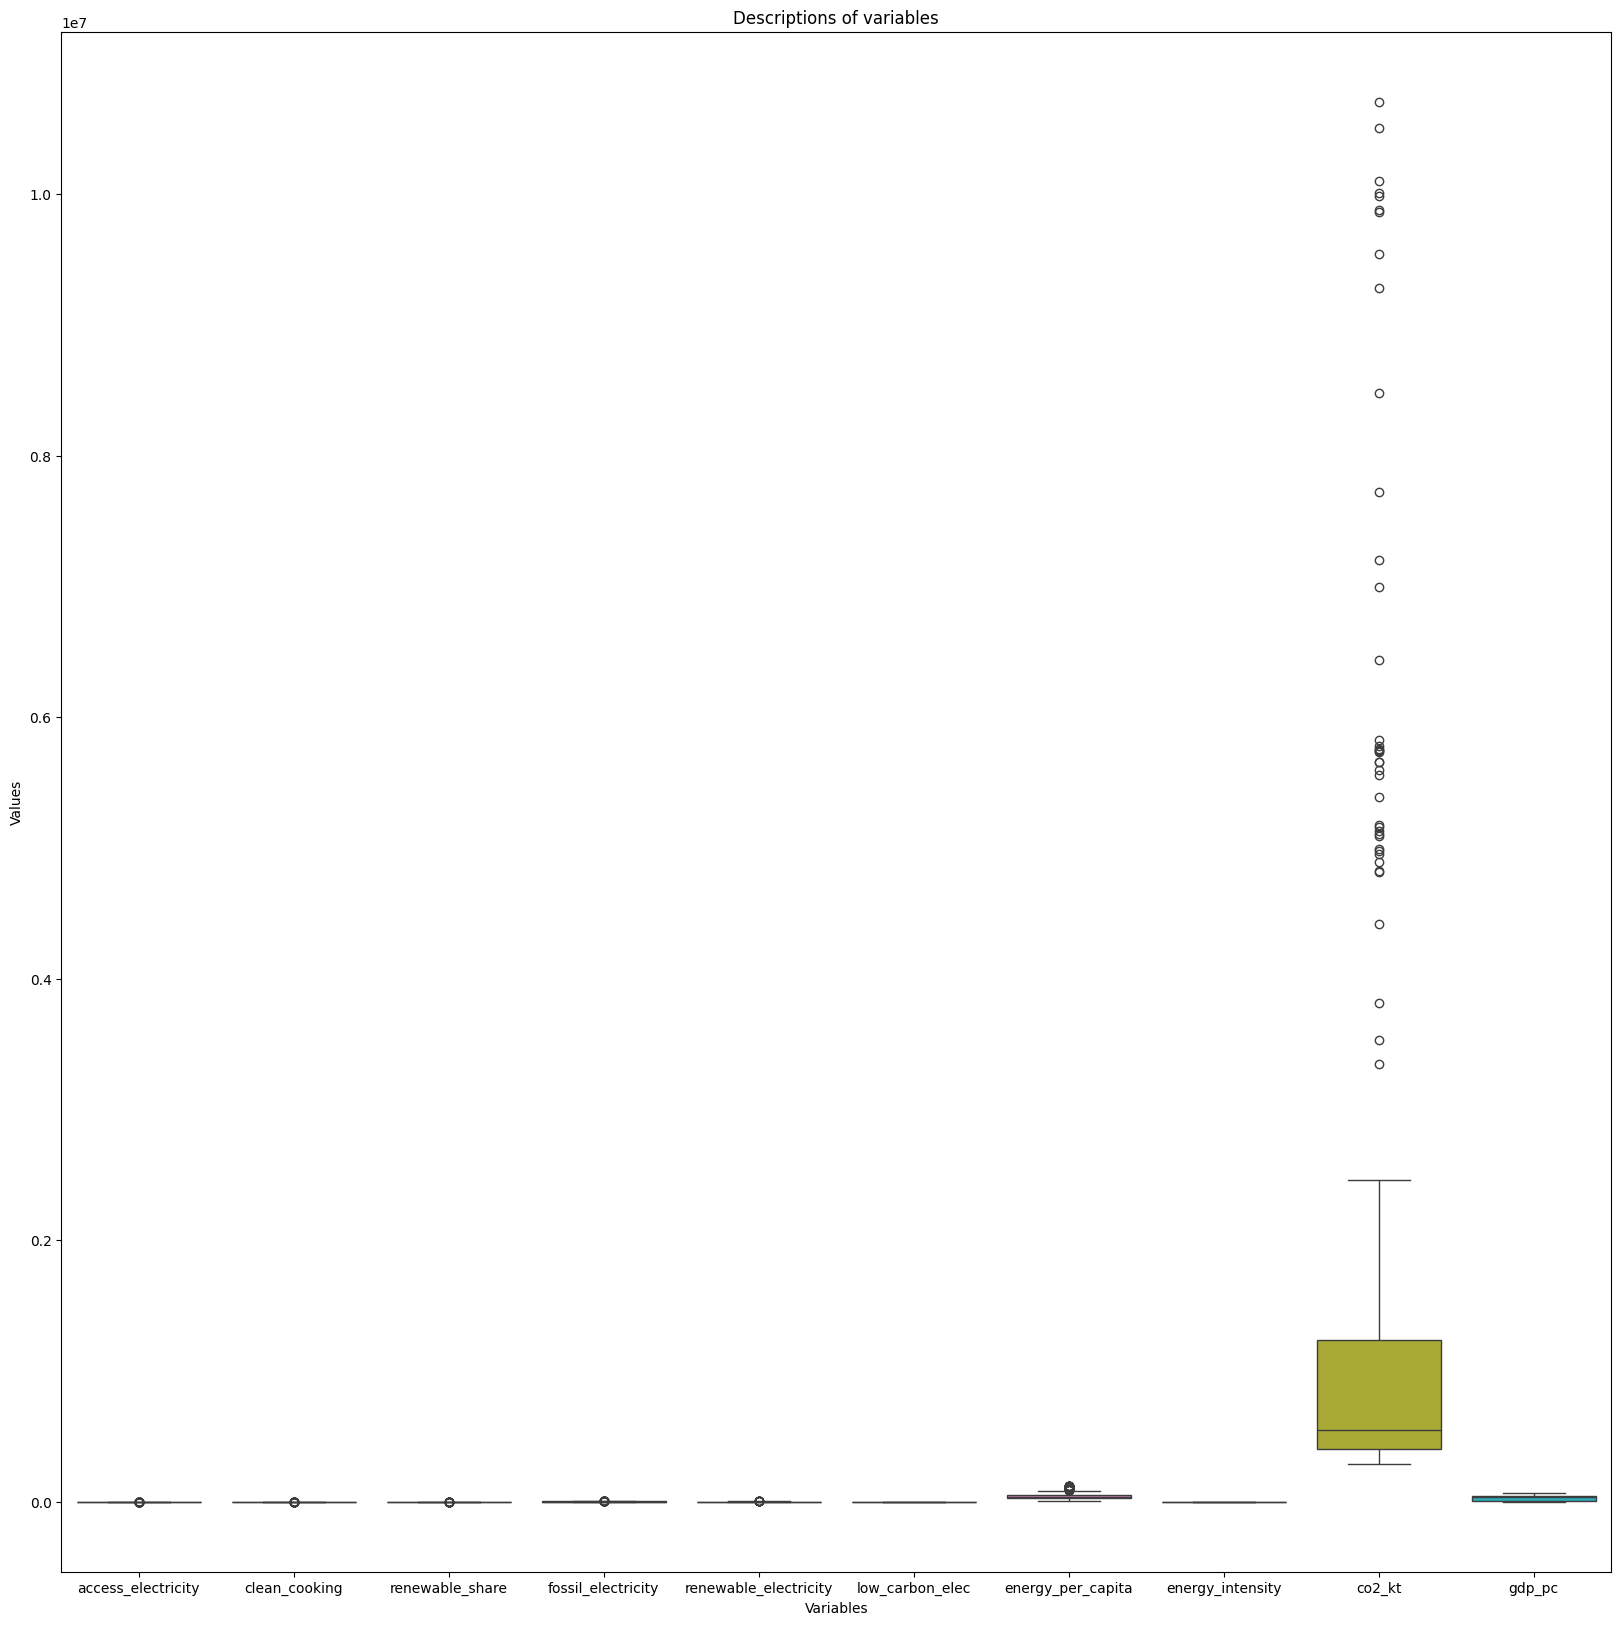

In [7]:
plt.figure(figsize=(20,20))
sns.boxplot(data=df[vars])
plt.title('Descriptions of variables')
plt.xlabel('Variables')
plt.ylabel('Values')
plt.show()

# Are the variables you are considering normally distributed?

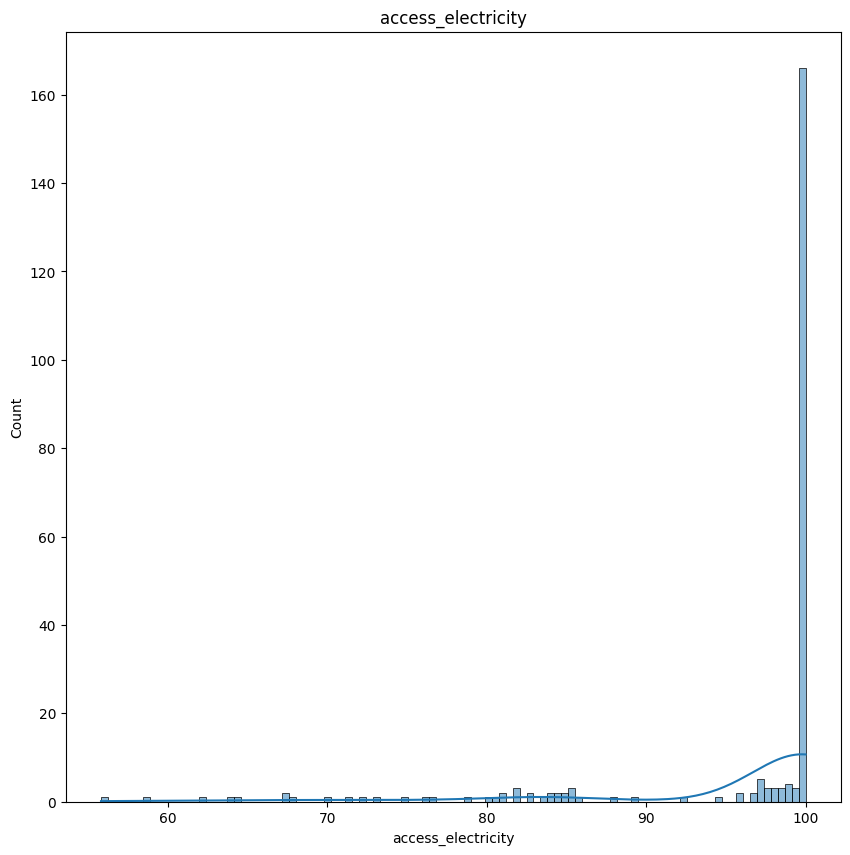

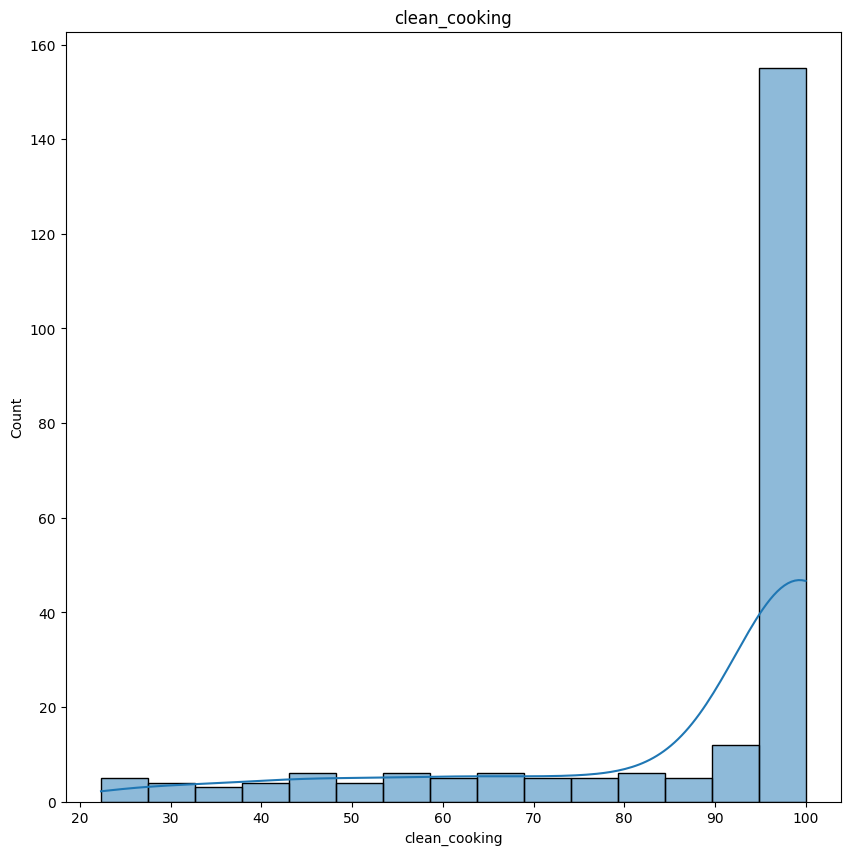

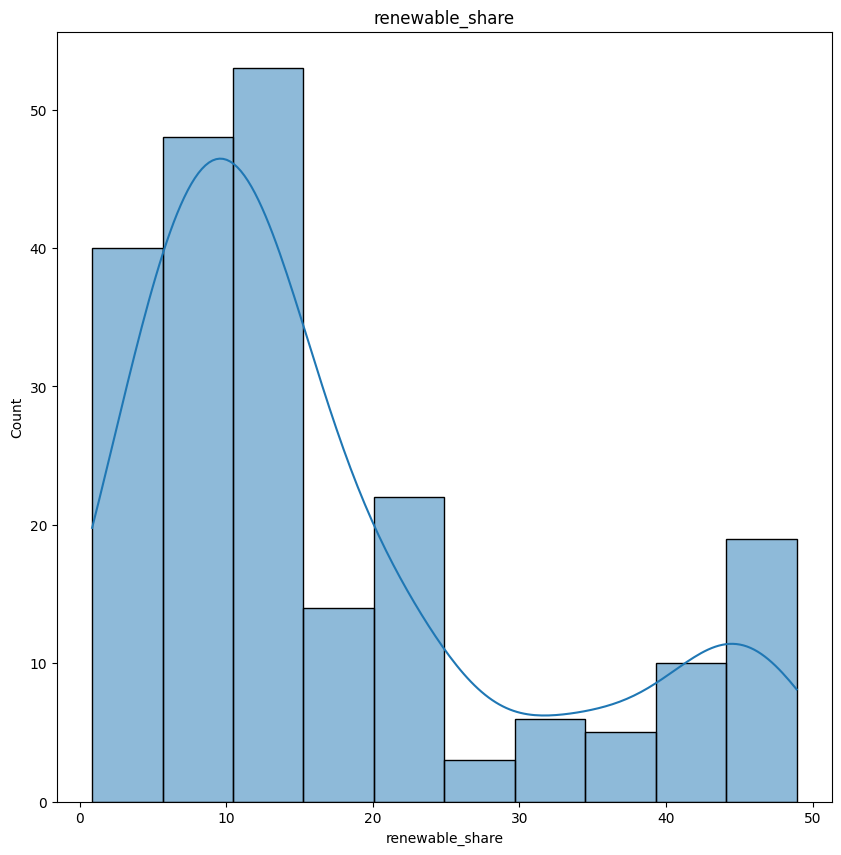

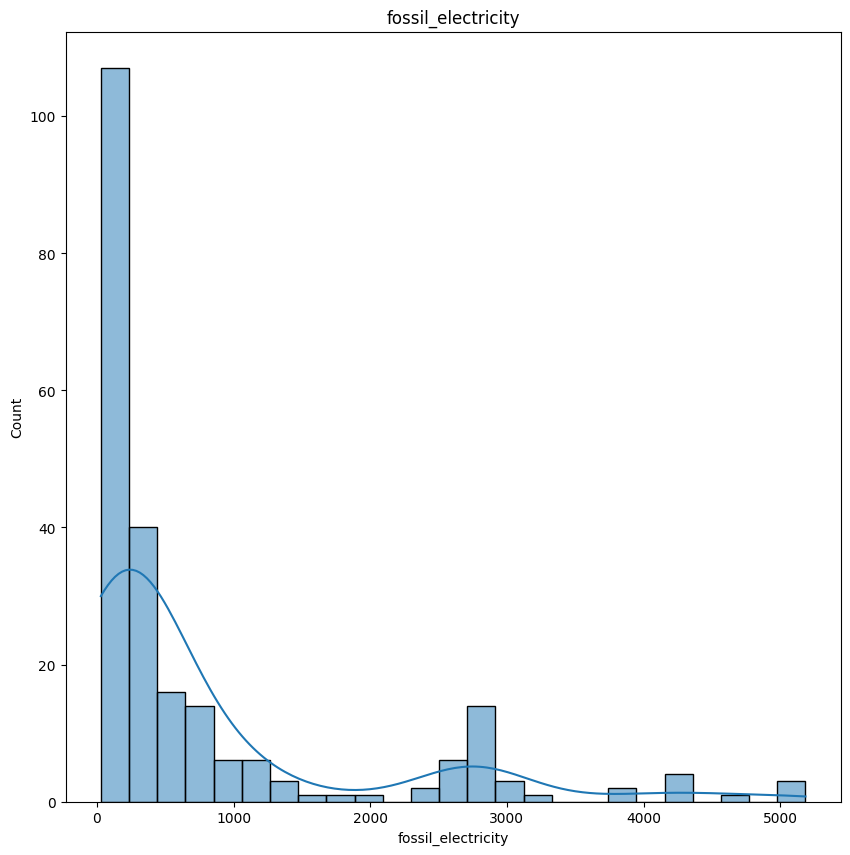

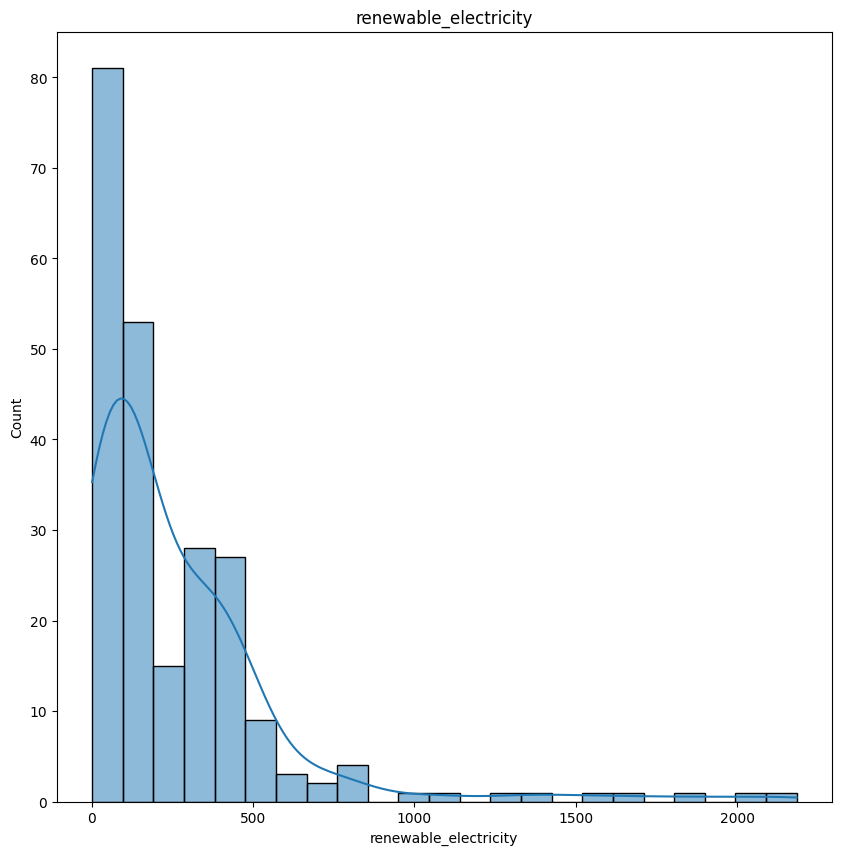

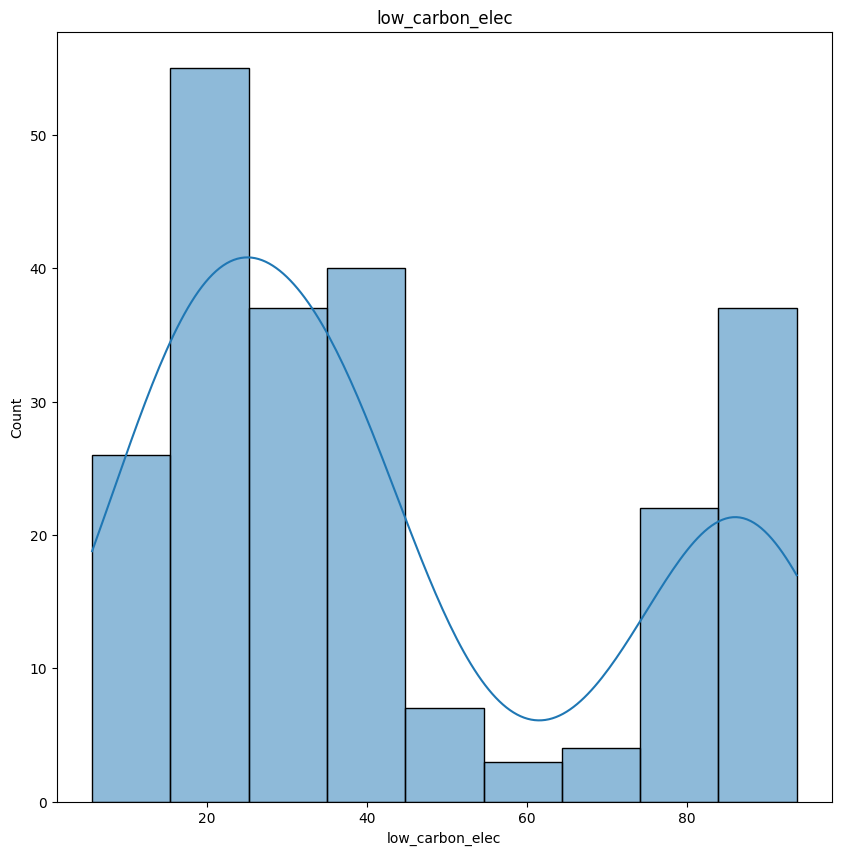

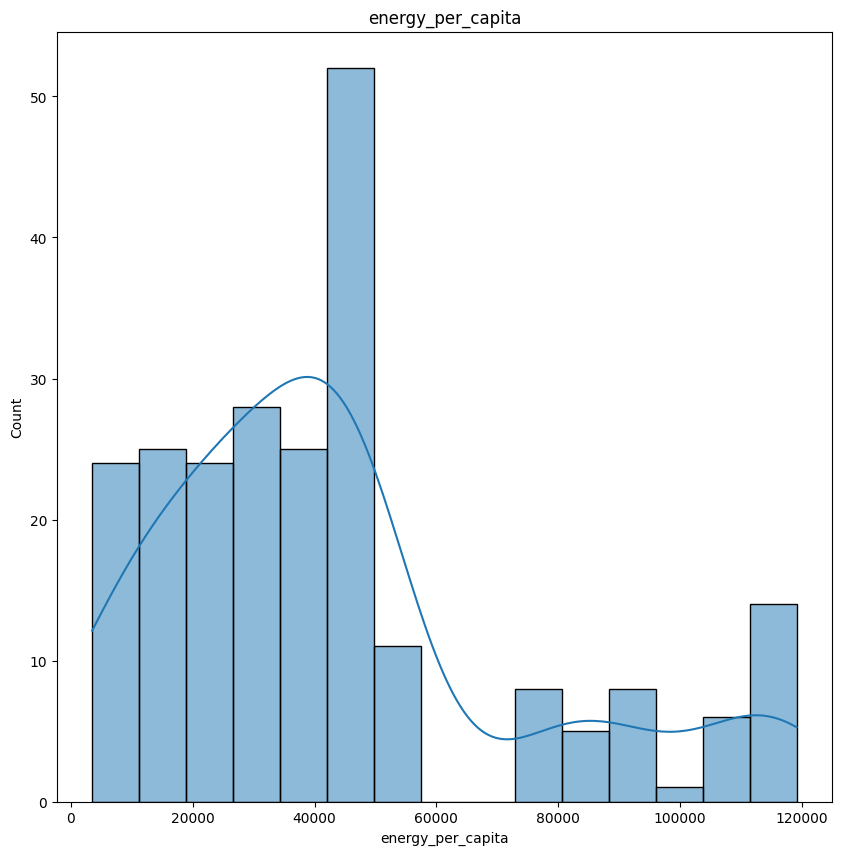

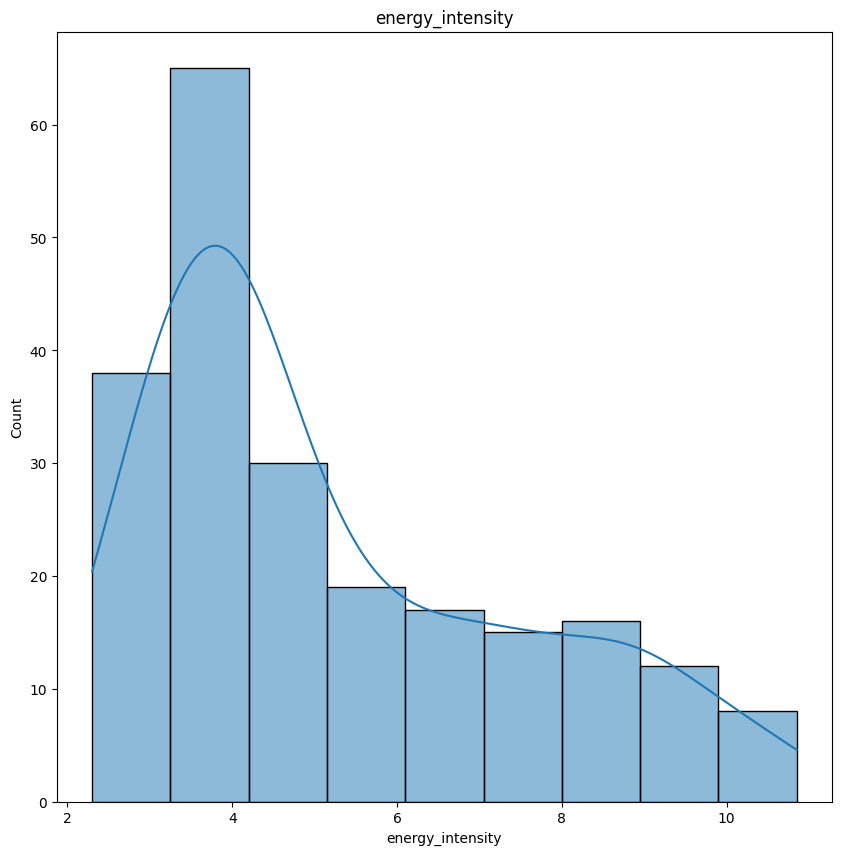

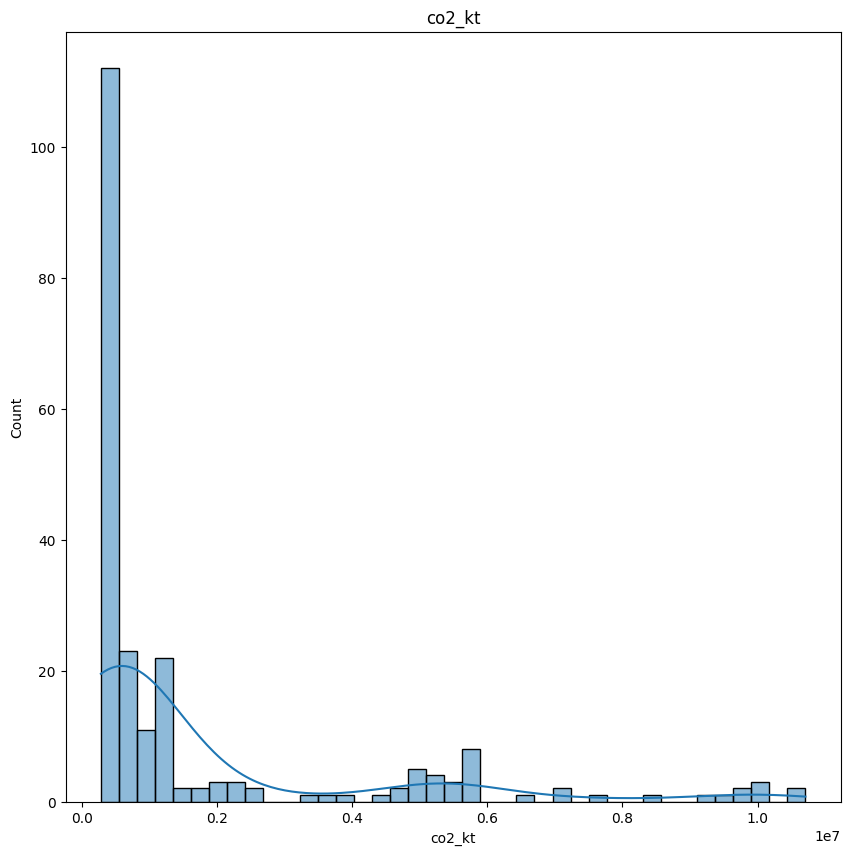

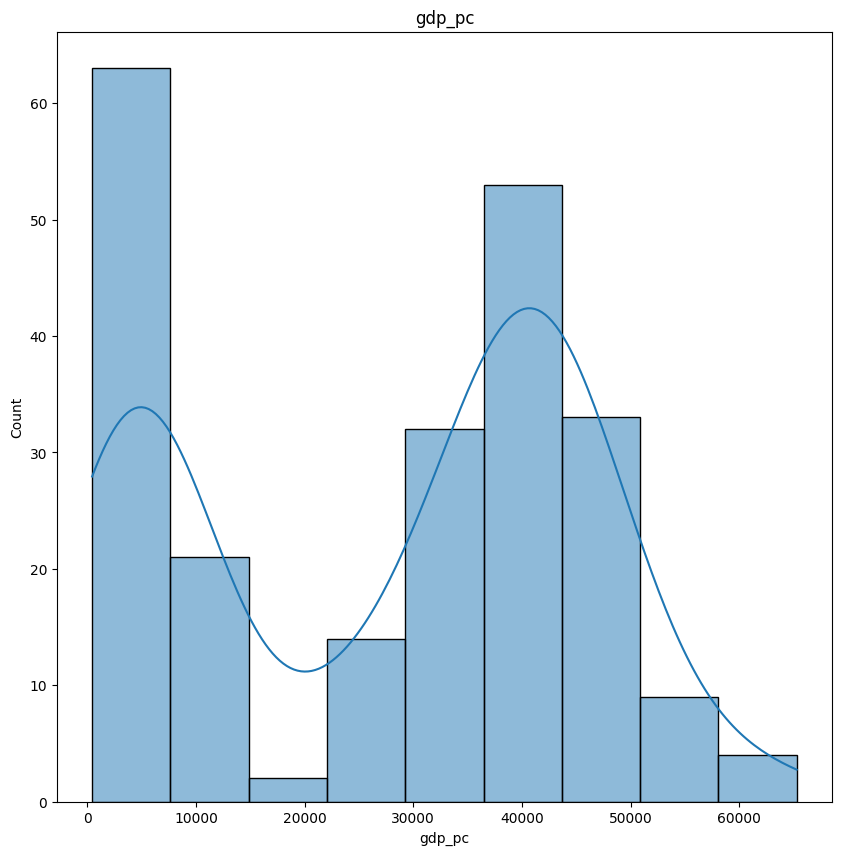

In [8]:
for var in vars:
  plt.figure(figsize=(10,10))
  sns.histplot(df[var], kde=True)
  plt.title(var)
  plt.show()

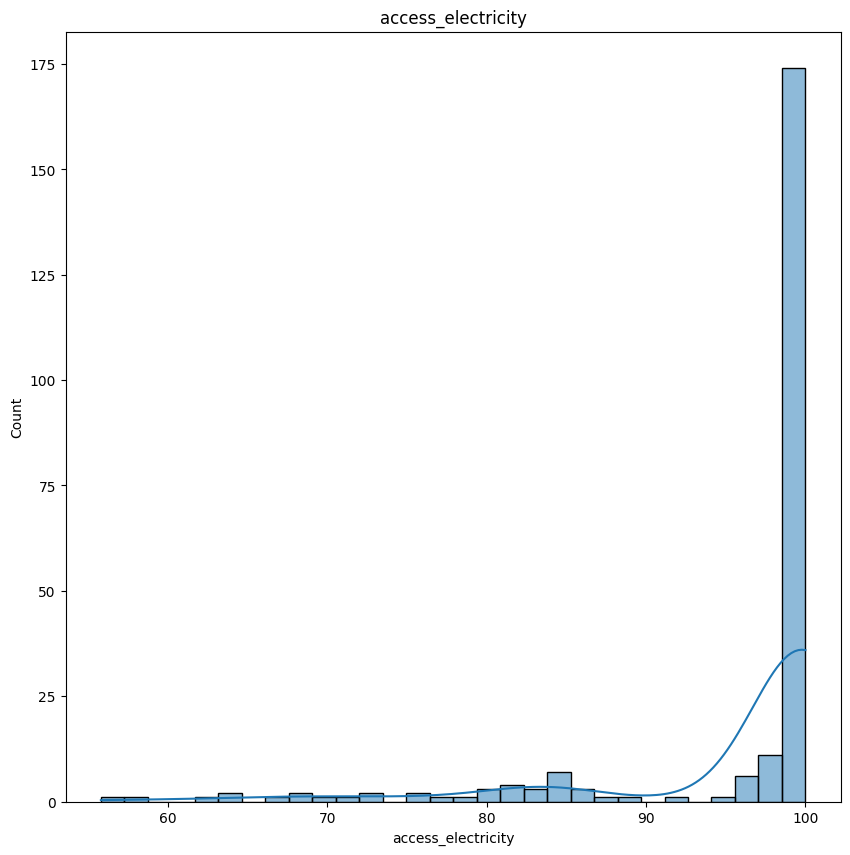

In [9]:
plt.figure(figsize=(10,10))
sns.histplot(df['access_electricity'], kde=True, bins=30)
plt.title('access_electricity')
plt.show()

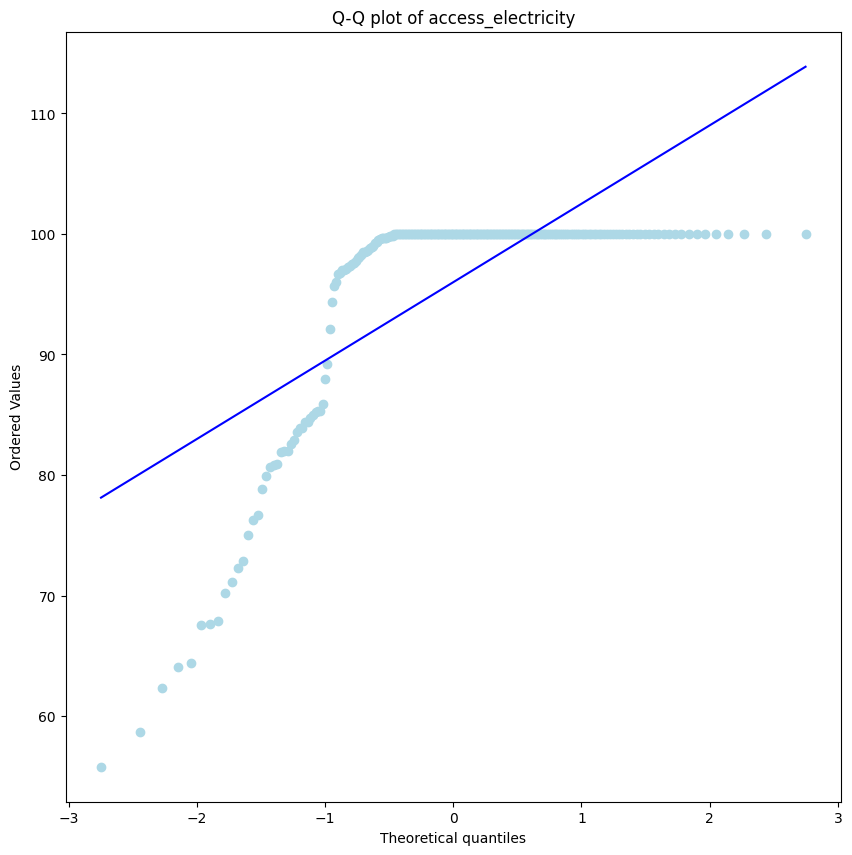

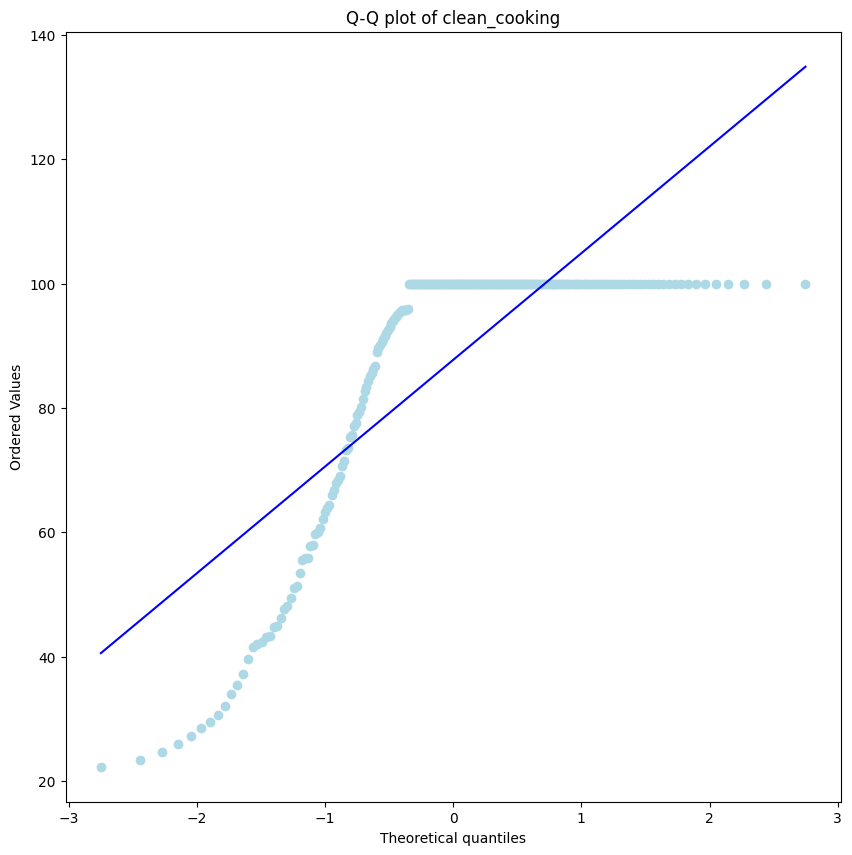

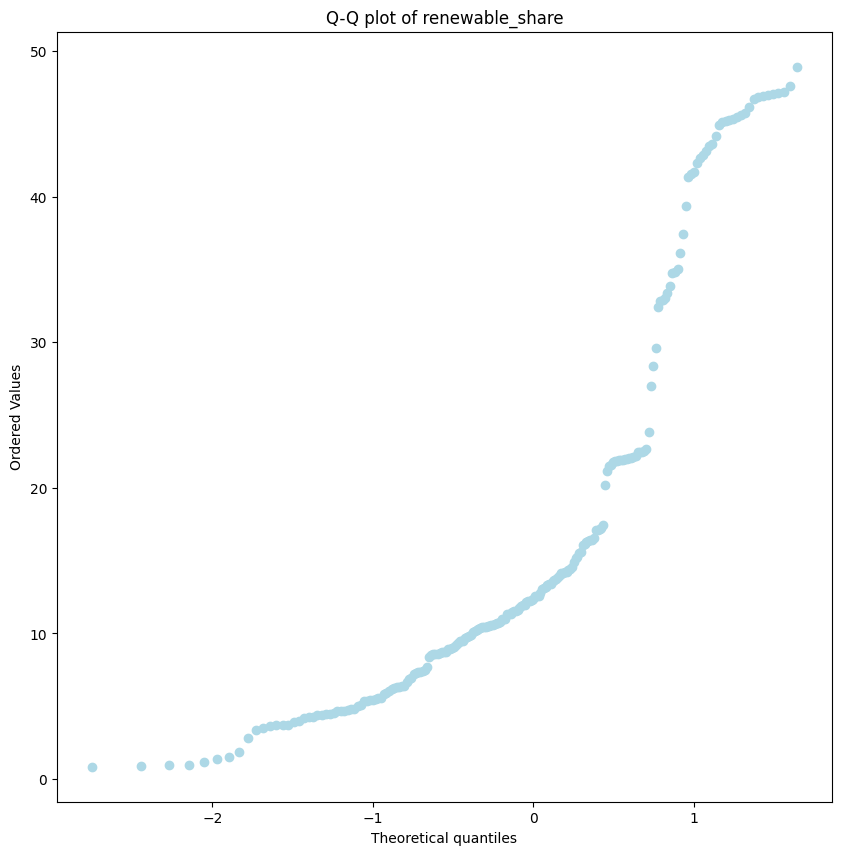

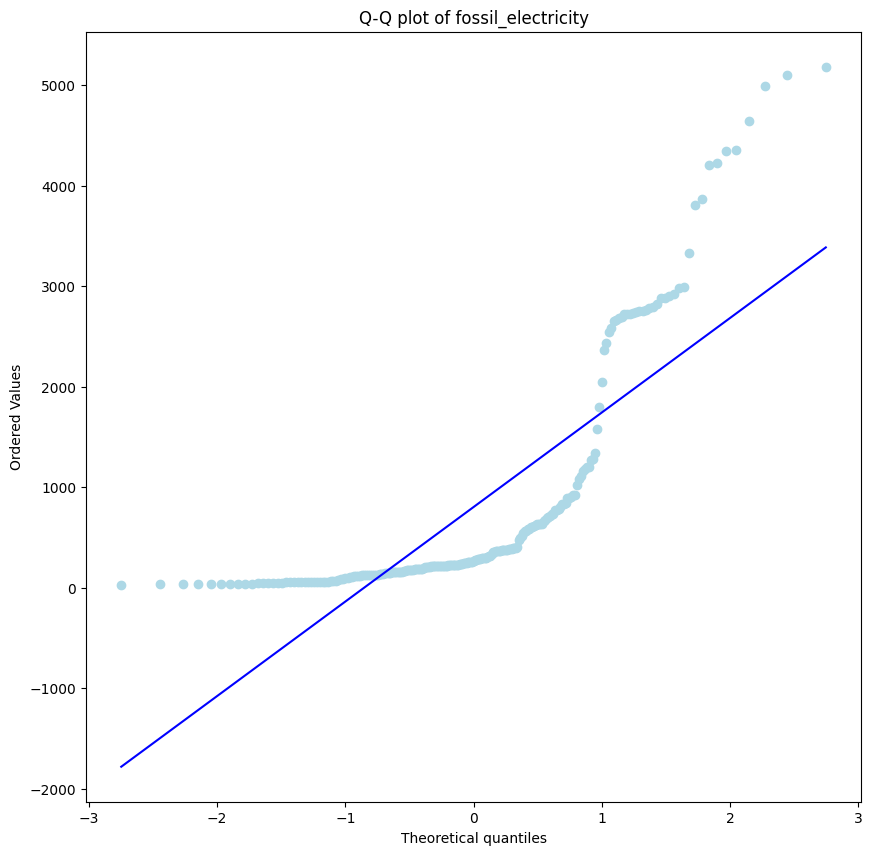

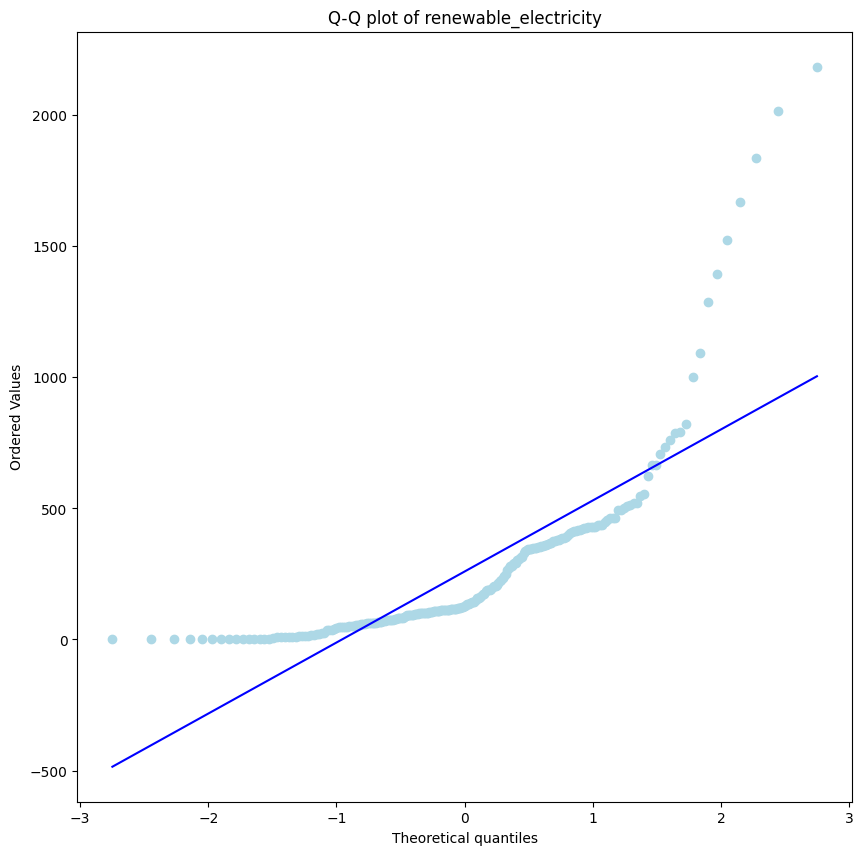

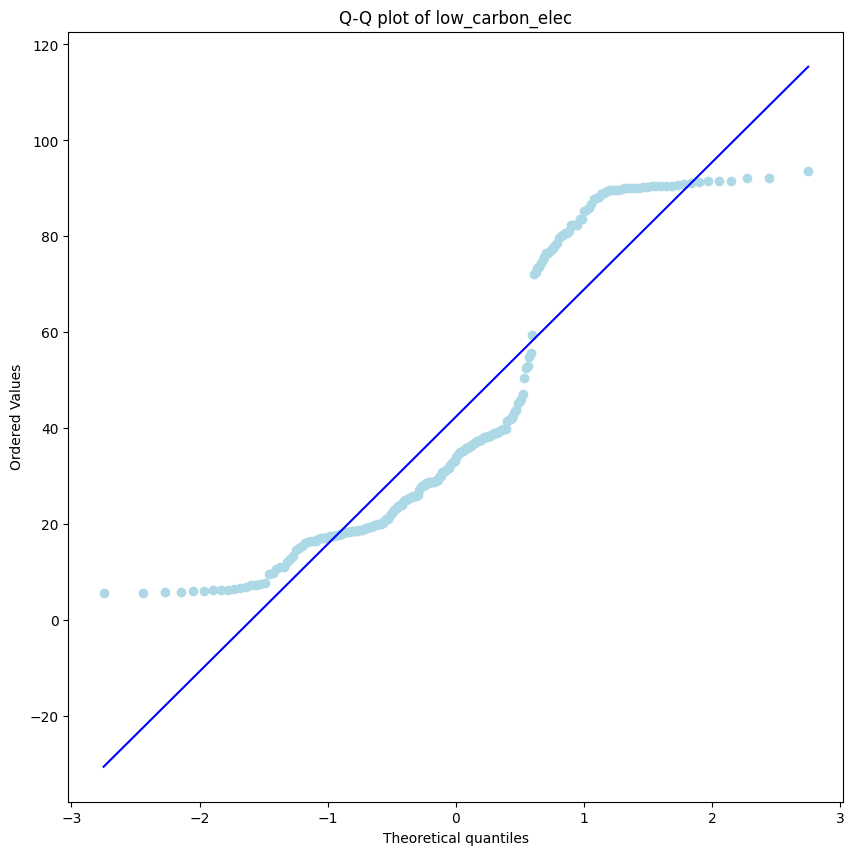

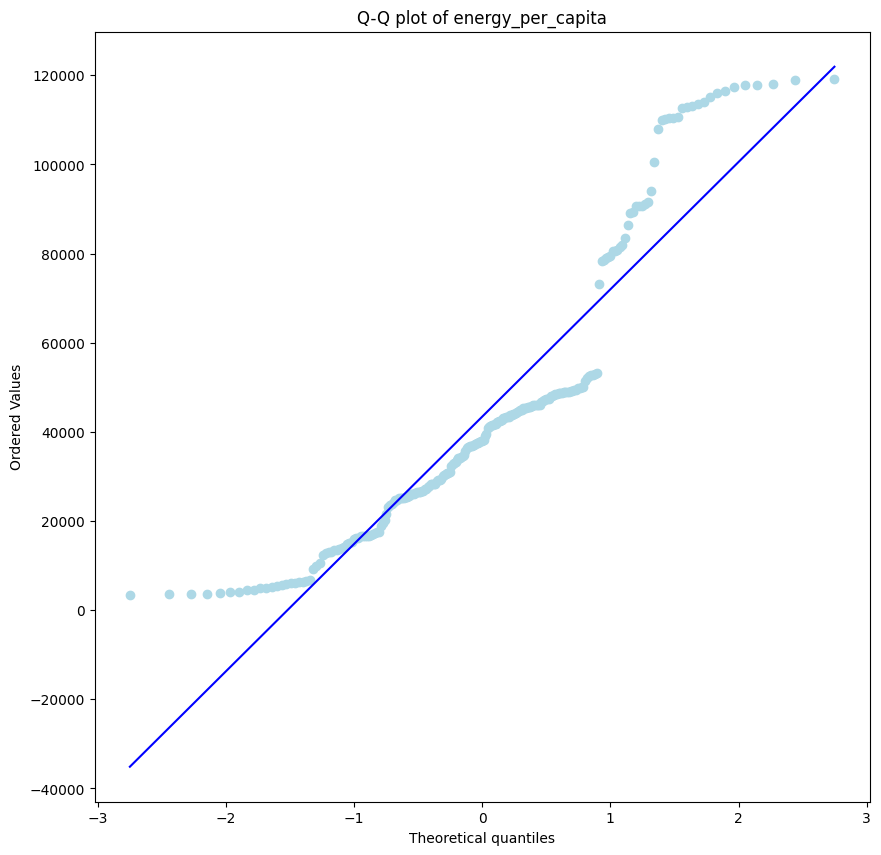

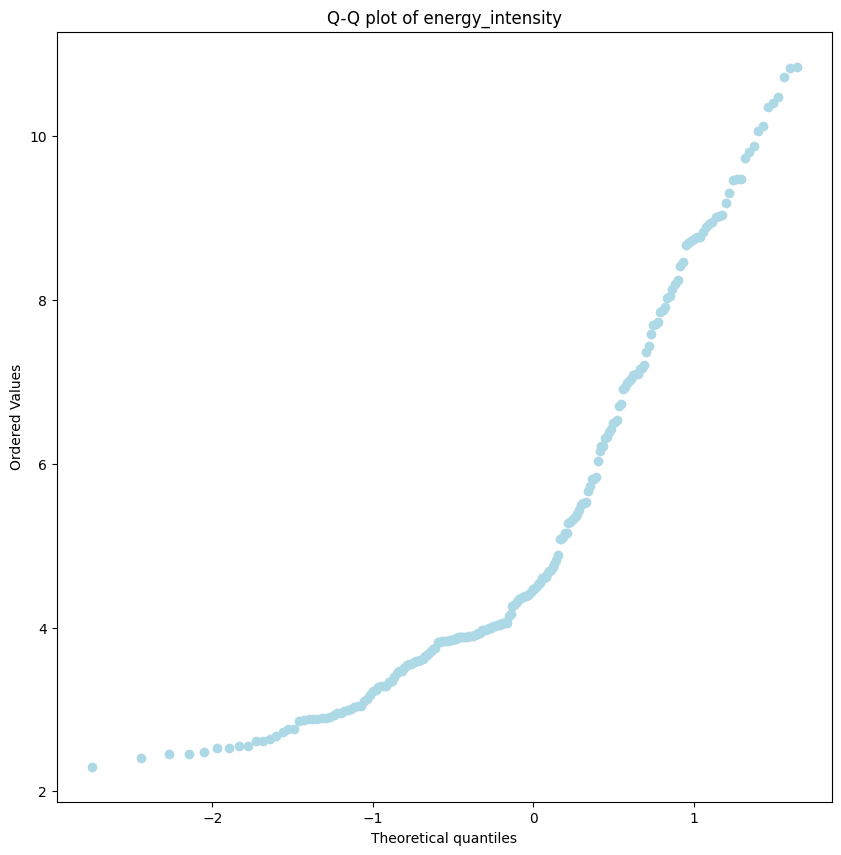

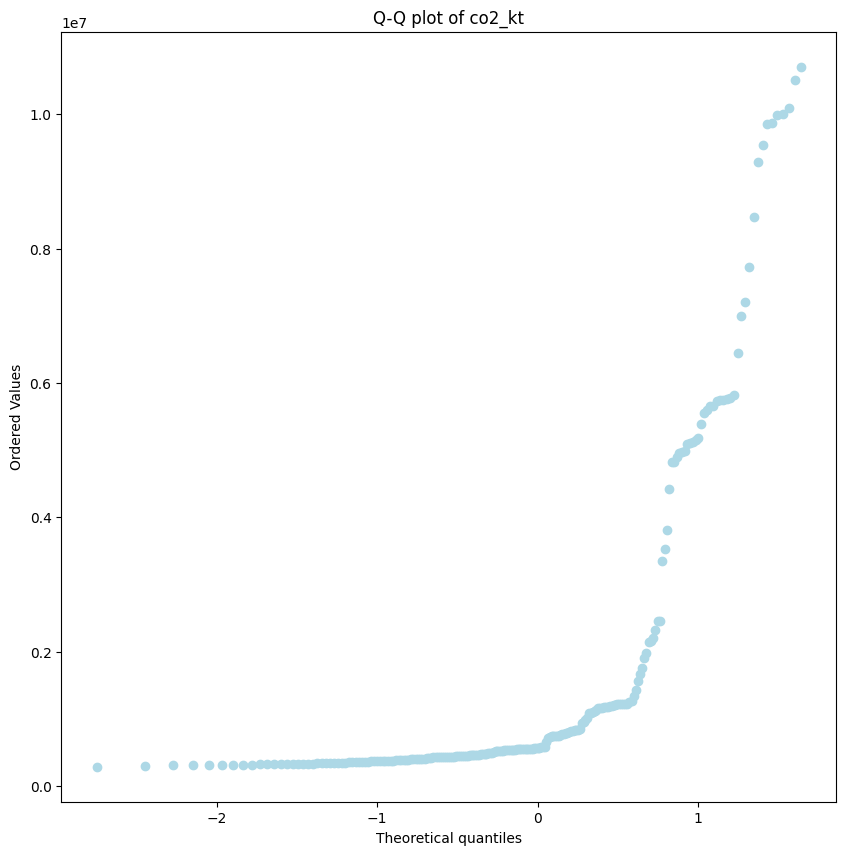

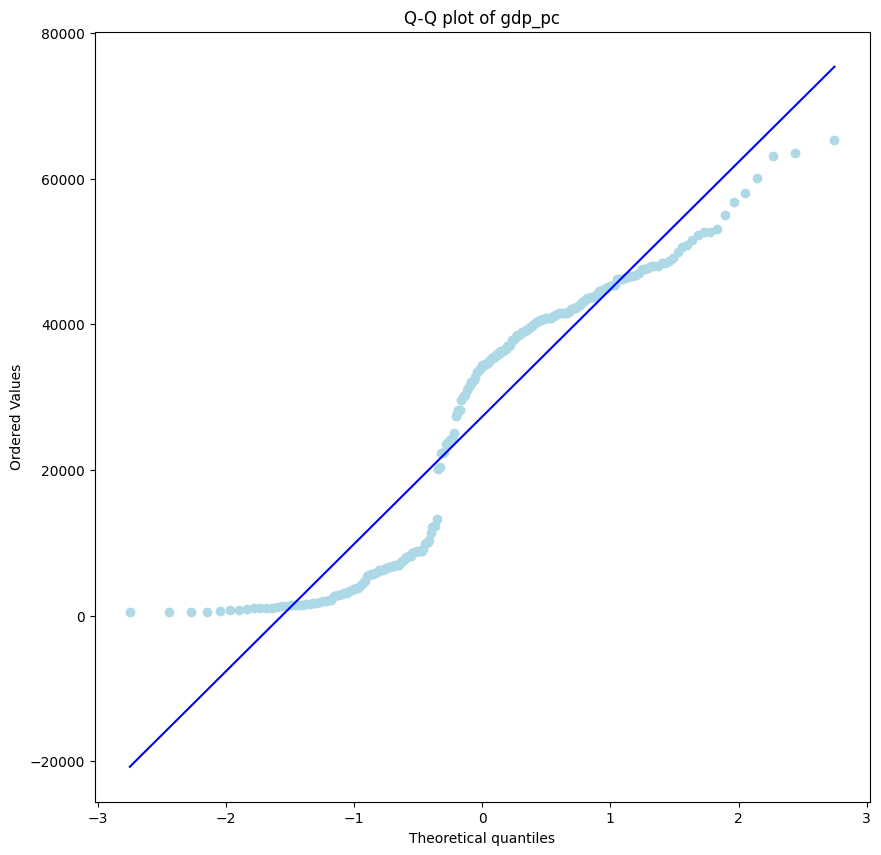

In [10]:
for var in vars:
  plt.figure(figsize=(10,10))
  stats.probplot(df[var], dist="norm", plot=plt)
  plt.title(f'Q-Q plot of {var}')
  lines = plt.gca().get_lines()
  lines[0].set_markerfacecolor('lightblue')
  lines[0].set_markeredgecolor('lightblue')
  lines[1].set_color('blue')
  plt.show()

# Create visualizations that clarify the data

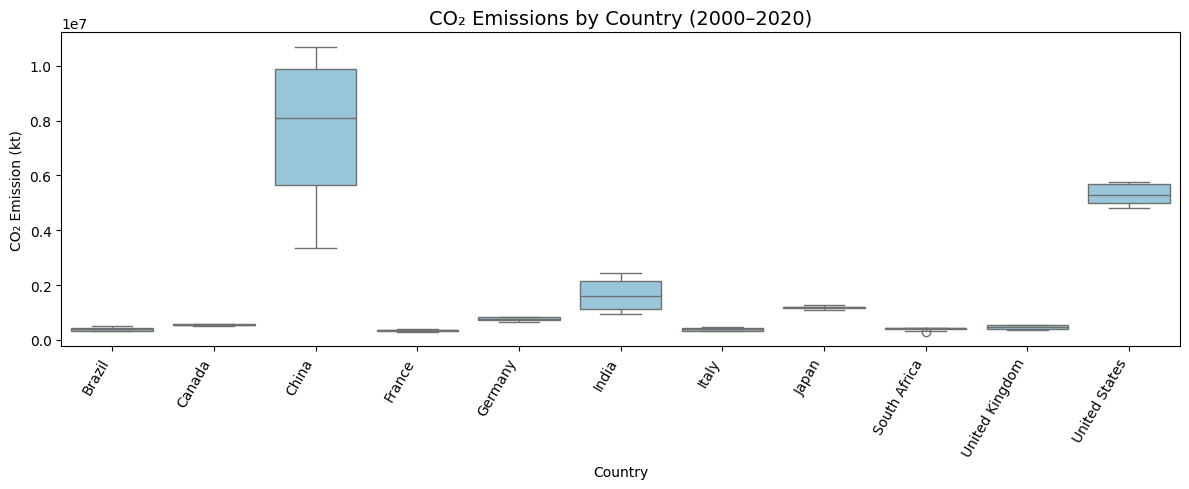

In [11]:
#different countries' co2 emission
plt.figure(figsize=(12, 5))
sns.boxplot(
    data=df,
    x="country",
    y="co2_kt",
    color="#8ecae6")

plt.xticks(rotation=60, ha="right")
plt.title("CO₂ Emissions by Country (2000–2020)", fontsize=14)
plt.xlabel("Country")
plt.ylabel("CO₂ Emission (kt)")
plt.tight_layout()
plt.show()

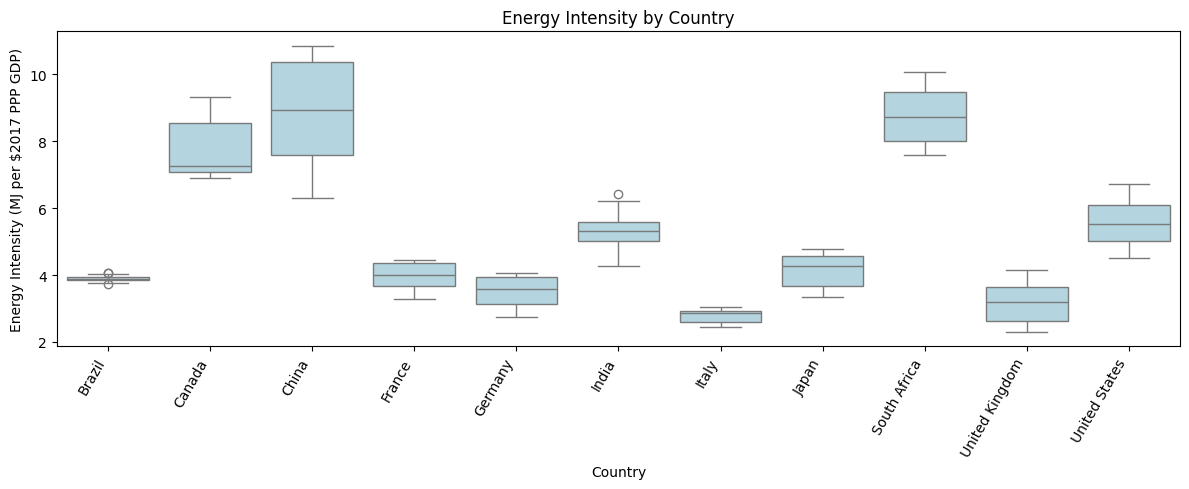

In [12]:
plt.figure(figsize=(12, 5))
sns.boxplot(
    data=clean_df,
    x="country",
    y="energy_intensity",
    color="lightblue")
plt.xticks(rotation=60, ha="right")
plt.title("Energy Intensity by Country")
plt.xlabel("Country")
plt.ylabel("Energy Intensity (MJ per $2017 PPP GDP)")
plt.tight_layout()
plt.show()

/tmp/ipython-input-1213220132.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


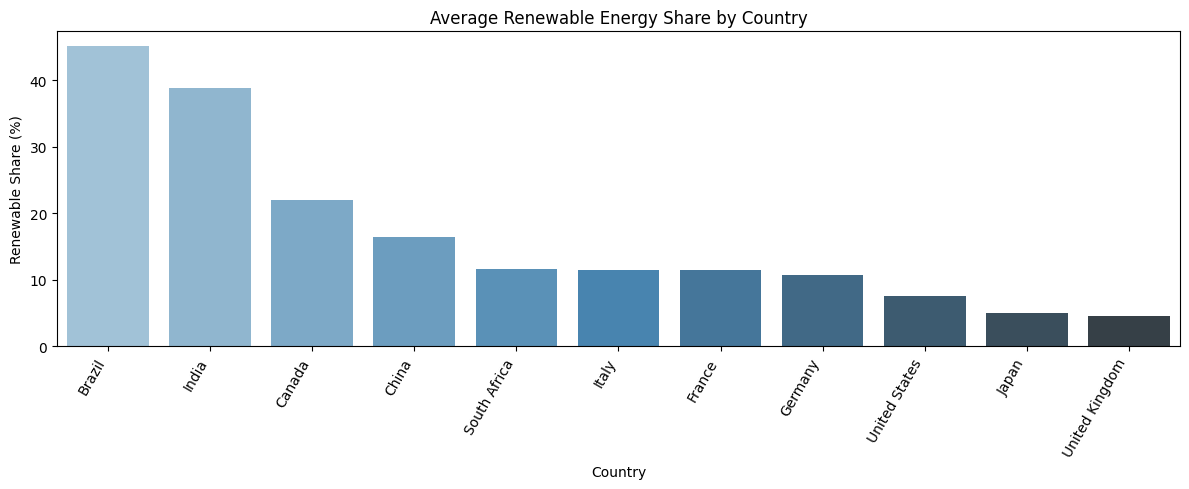

In [13]:
#ave_renewable_share rating
renewable_mean = (
    clean_df.groupby("country")["renewable_share"]
    .mean()
    .sort_values(ascending=False)
    .reset_index())

plt.figure(figsize=(12, 5))
sns.barplot(
    data=renewable_mean,
    x="country",
    y="renewable_share",
    palette="Blues_d")
plt.xticks(rotation=60, ha="right")
plt.title("Average Renewable Energy Share by Country")
plt.xlabel("Country")
plt.ylabel("Renewable Share (%)")
plt.tight_layout()
plt.show()

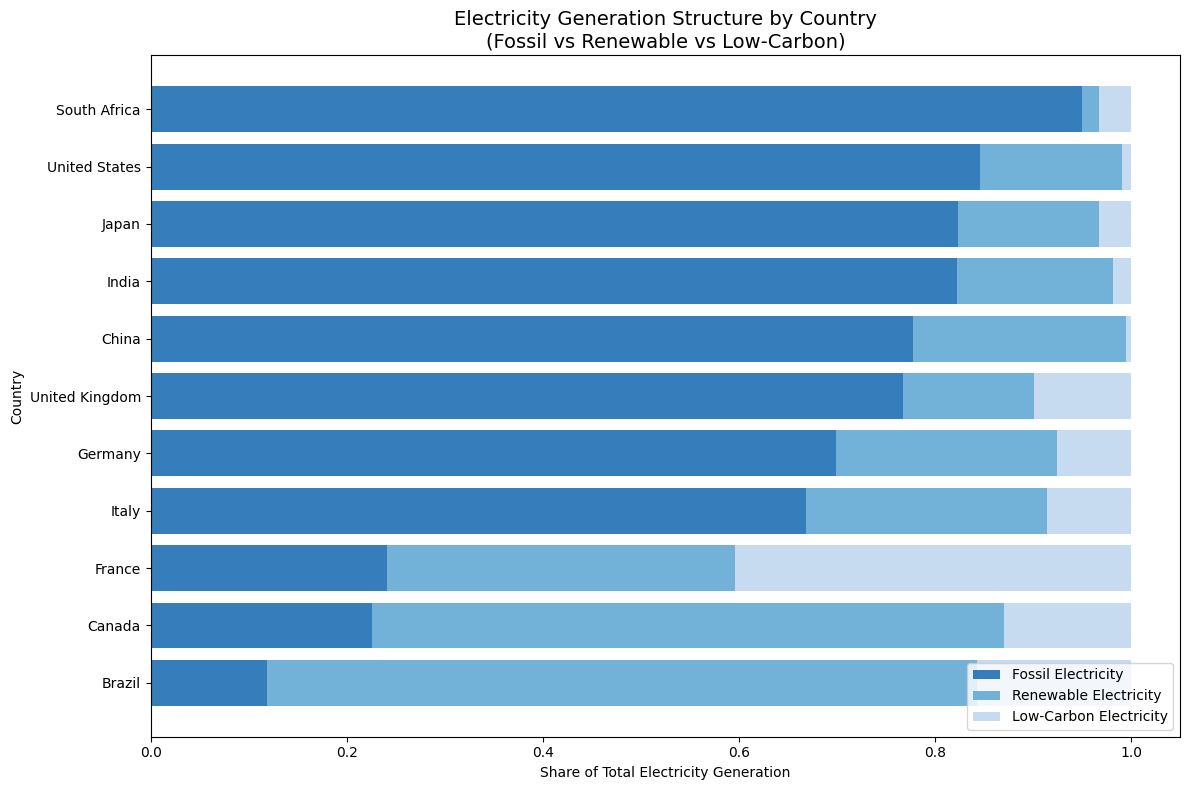

In [14]:
# proportion
country_energy = clean_df.groupby("country")[[
    "fossil_electricity",
    "renewable_electricity",
    "low_carbon_elec"]].mean()

total = (
    country_energy["fossil_electricity"]
    + country_energy["renewable_electricity"]
    + country_energy["low_carbon_elec"])

country_energy["fossil_share"] = country_energy["fossil_electricity"] / total
country_energy["renewable_share"] = country_energy["renewable_electricity"] / total
country_energy["lowcarbon_share"] = country_energy["low_carbon_elec"] / total

# --- ranking（fossil Share） ---
country_energy = country_energy.sort_values("fossil_share", ascending=True)
colors = sns.color_palette("Blues", n_colors=3)
plt.figure(figsize=(12, 8))

plt.barh(country_energy.index, country_energy["fossil_share"],
         color=colors[2], label="Fossil Electricity", alpha=0.9)
plt.barh(country_energy.index, country_energy["renewable_share"],
         left=country_energy["fossil_share"],
         color=colors[1], label="Renewable Electricity", alpha=0.95)
plt.barh(country_energy.index, country_energy["lowcarbon_share"],
         left=country_energy["fossil_share"] + country_energy["renewable_share"],
         color=colors[0], label="Low-Carbon Electricity", alpha=1)

plt.title("Electricity Generation Structure by Country\n(Fossil vs Renewable vs Low-Carbon)", fontsize=14)
plt.xlabel("Share of Total Electricity Generation")
plt.ylabel("Country")

plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


# Are there outliers?

#If so, how are you handling these variables?

In [15]:
for var in vars:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[(df[var] < lower_bound) | (df[var] > upper_bound)]
    print(f"\nVariable: {var}")
    print(f"Number of outliers: {len(outliers)}")
    if not outliers.empty:
        print(f"Outlier values (first 5):\n{outliers[[var]].head()}")

    # Handling outliers
    df_cleaned = df[(df[var] >= lower_bound) & (df[var] <= upper_bound)]
    print(f"Number of rows after removing outliers for {var}: {len(df_cleaned)}")



Variable: access_electricity
Number of outliers: 42
Outlier values (first 5):
      access_electricity
483             94.39172
484             96.01653
1534            58.72147
1535            55.80000
1536            62.30000
Number of rows after removing outliers for access_electricity: 189

Variable: clean_cooking
Number of outliers: 32
Outlier values (first 5):
     clean_cooking
714       42.00000
715       42.30000
716       43.10000
717       43.40000
718       44.90000
Number of rows after removing outliers for clean_cooking: 199

Variable: renewable_share
Number of outliers: 19
Outlier values (first 5):
     renewable_share
486         45.11000
487         45.18000
488         46.13000
489         46.67000
490         47.19000
Number of rows after removing outliers for renewable_share: 201

Variable: fossil_electricity
Number of outliers: 38
Outlier values (first 5):
     fossil_electricity
718          1795.41000
719          2042.80000
720          2364.16000
721          

In [16]:
# long tail variables--log transformation
for col in ["co2_kt", "fossil_electricity", "renewable_electricity",
            "energy_per_capita", "gdp_pc"]:
    clean_df[f"log_{col}"] = np.log(clean_df[col] + 1)

In [17]:
clean_df["log_co2_kt"] = np.log(clean_df["co2_kt"] + 1)
clean_df["log_fossil_electricity"] = np.log(clean_df["fossil_electricity"] + 1)
clean_df["log_energy_per_capita"] = np.log(clean_df["energy_per_capita"] + 1)
clean_df["log_gdp_pc"] = np.log(clean_df["gdp_pc"] + 1)
clean_df.head()

,access_electricity,clean_cooking,renewable_share,fossil_electricity,renewable_electricity,low_carbon_elec,energy_per_capita,energy_intensity,co2_kt,gdp_pc,country,year,log_co2_kt,log_fossil_electricity,log_renewable_electricity,log_energy_per_capita,log_gdp_pc
483,94.39172,89.00000,42.66000,28.87000,308.77000,91.57278,13400.32000,3.88000,313670.00000,3749.91085,Brazil,2000,12.65610,3.39685,5.73583,9.50311,8.22975
484,96.01653,89.70000,41.33000,35.19000,273.71000,89.11100,12893.82800,3.90000,319380.00000,3160.24935,Brazil,2001,12.67414,3.58878,5.61572,9.46458,8.05872
485,96.65299,90.10000,42.85000,33.50000,292.95000,90.15546,13021.79100,3.89000,317760.00980,2839.49150,Brazil,2002,12.66905,3.54096,5.68341,9.47446,7.95173
486,96.98010,90.60000,45.11000,31.62000,313.88000,91.18975,13111.92300,3.91000,310809.99760,3070.43642,Brazil,2003,12.64694,3.48493,5.75219,9.48135,8.02990
487,96.76511,91.10000,45.18000,40.14000,329.43000,89.46926,13593.70000,3.90000,328519.98900,3637.31389,Brazil,2004,12.70236,3.71698,5.80039,9.51744,8.19928


# Identify other patterns in the data that may be  of interest in your analysis. Explain your position.

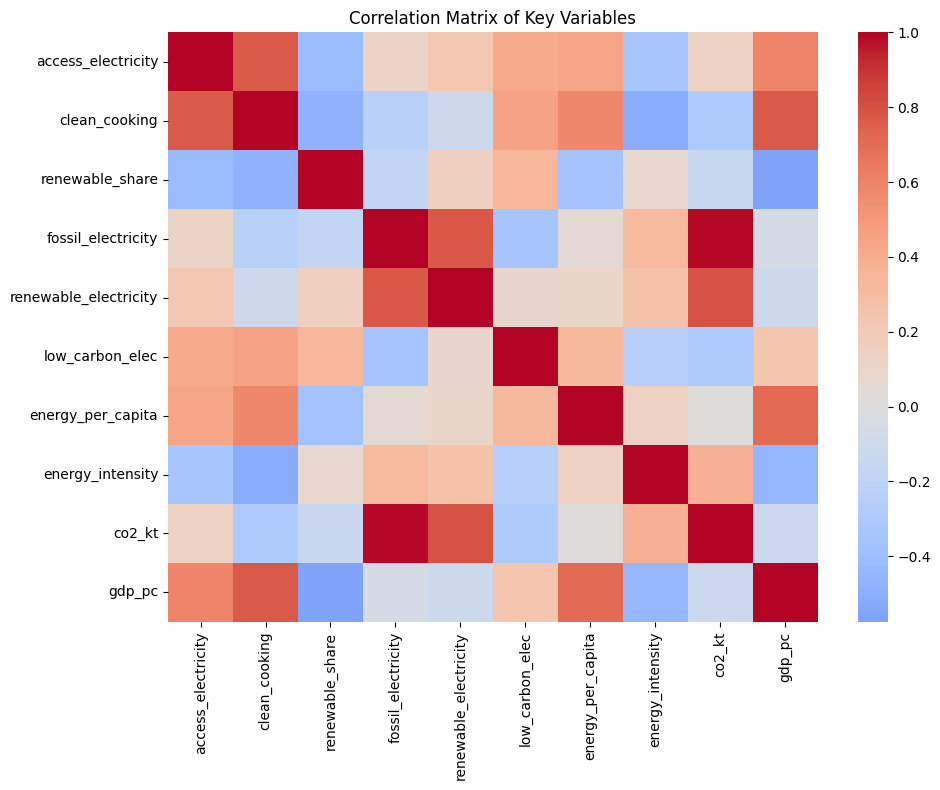

In [18]:
corr = clean_df[vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Key Variables")
plt.tight_layout()
plt.show()

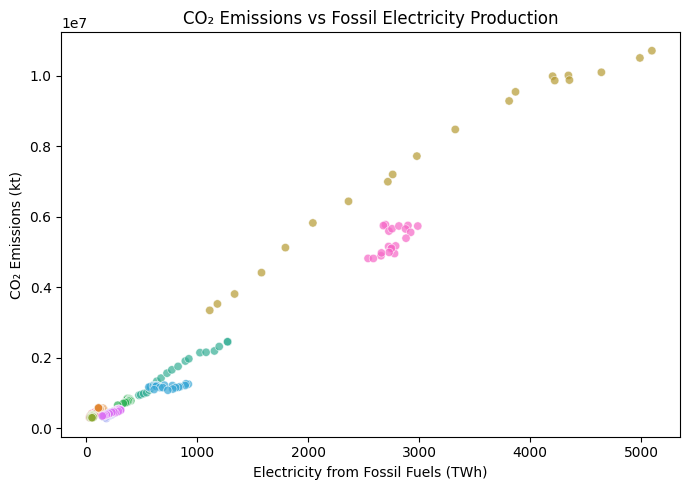

In [19]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=clean_df,
    x="fossil_electricity",
    y="co2_kt",
    hue="country",
    alpha=0.7,
    legend=False)
plt.title("CO₂ Emissions vs Fossil Electricity Production")
plt.xlabel("Electricity from Fossil Fuels (TWh)")
plt.ylabel("CO₂ Emissions (kt)")
plt.tight_layout()
plt.show()


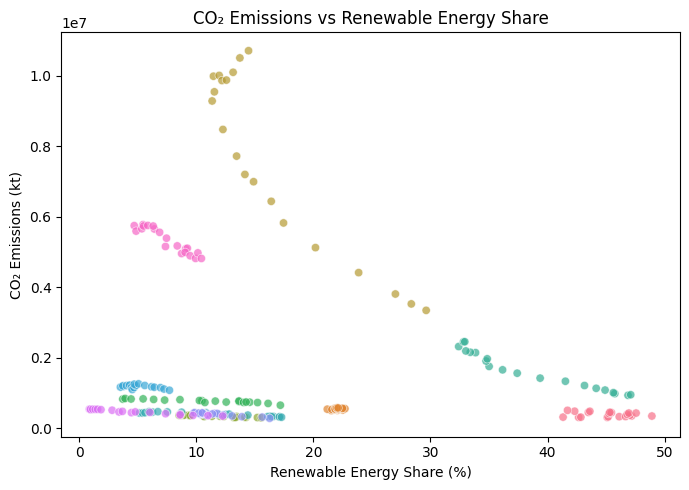

In [20]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=clean_df,
    x="renewable_share",
    y="co2_kt",
    hue="country",
    alpha=0.7,
    legend=False)
plt.title("CO₂ Emissions vs Renewable Energy Share")
plt.xlabel("Renewable Energy Share (%)")
plt.ylabel("CO₂ Emissions (kt)")
plt.tight_layout()
plt.show()


# Modeling

In [21]:
# Model 1: log_CO2 ~ fossil + renewable share
model1 = smf.ols(
    formula="log_co2_kt ~ log_fossil_electricity + renewable_share",
    data=clean_df).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:             log_co2_kt   R-squared:                       0.891
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     884.6
Date:                Tue, 09 Dec 2025   Prob (F-statistic):          4.69e-105
Time:                        21:43:46   Log-Likelihood:                -77.024
No. Observations:                 220   AIC:                             160.0
Df Residuals:                     217   BIC:                             170.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  8

In [22]:
# Model 2: add energy_per_capita and energy_intensity
model2 = smf.ols(
    formula="""log_co2_kt ~ log_fossil_electricity
                     + renewable_share
                     + log_energy_per_capita
                     + energy_intensity""",data=clean_df).fit()

print(model2.summary())


                            OLS Regression Results                            
Dep. Variable:             log_co2_kt   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.910
Method:                 Least Squares   F-statistic:                     554.0
Date:                Tue, 09 Dec 2025   Prob (F-statistic):          5.77e-112
Time:                        21:43:46   Log-Likelihood:                -53.777
No. Observations:                 220   AIC:                             117.6
Df Residuals:                     215   BIC:                             134.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  6

In [23]:
# Model 3: add gdp_pc、clean_cooking、access_electricity、low_carbon_elec
model3 = smf.ols(
    formula="""
        log_co2_kt ~ log_fossil_electricity
                     + renewable_share
                     + log_energy_per_capita
                     + energy_intensity
                     + log_gdp_pc
                     + clean_cooking
                     + access_electricity
                     + low_carbon_elec""",data=clean_df).fit()

print(model3.summary())


                            OLS Regression Results                            
Dep. Variable:             log_co2_kt   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     1971.
Date:                Tue, 09 Dec 2025   Prob (F-statistic):          1.11e-193
Time:                        21:43:46   Log-Likelihood:                 155.39
No. Observations:                 220   AIC:                            -292.8
Df Residuals:                     211   BIC:                            -262.2
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  9

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
#VIF-model3
X = clean_df[[
    "log_fossil_electricity",
    "renewable_share",
    "log_energy_per_capita",
    "energy_intensity",
    "log_gdp_pc",
    "clean_cooking",
    "access_electricity",
    "low_carbon_elec"
]].copy()

# add number
X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]
vif_data


,variable,VIF
0,const,1543.05289
1,log_fossil_electricity,4.56292
2,renewable_share,5.31586
3,log_energy_per_capita,37.80813
4,energy_intensity,9.89048
5,log_gdp_pc,38.44601
6,clean_cooking,21.40050
7,access_electricity,4.97453
8,low_carbon_elec,6.68200
